# Notebook 03 — Base Model Benchmark
## FYP: Adaptive Explainable Ensemble for Pre-Launch Steam Game Reception Prediction
### Heshan Ratnaweera | IIT Sri Lanka | W2082289 | 2026

**Purpose:** Benchmark four classifiers (Logistic Regression, Random Forest, XGBoost, CatBoost)
on the full T4 feature set to establish a baseline and select the best classifier
for training specialist Models A–D in notebook 04.

**Inputs:** `data/processed/games_features_t4.csv`
**Outputs:** `outputs/results/benchmark_table.csv`
**Key results:** *(fill in after running)*

---
## Contents
1. Setup & Imports
2. Load Dataset
3. Train-Test Split
4. Define Classifiers
5. Cross-Validation Benchmark
6. Class Imbalance Strategy Comparison
7. Results Visualisation
8. Winner Selection
9. Save Benchmark Table


## 1. Setup & Imports

In [1]:
import sys
import warnings
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine learning ───────────────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics         import (f1_score, roc_auc_score, precision_score,
                                     recall_score, confusion_matrix,
                                     ConfusionMatrixDisplay, classification_report)
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline

from xgboost  import XGBClassifier
from catboost import CatBoostClassifier

# SMOTE for class imbalance handling
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline      import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    print('imbalanced-learn not installed — SMOTE comparison will be skipped')
    print('Install with: pip install imbalanced-learn')
    SMOTE_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')

# ── Add project root to path ───────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FEATURES_T4_CSV, RESULTS_DIR, FIGURES_DIR,
    TARGET_COL, RANDOM_STATE, CV_FOLDS,
    TIER1_FEATURES, TIER2_FEATURES, TIER3_FEATURES
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('All imports OK')
print(f'Project root : {PROJECT_ROOT}')
print(f'Input CSV    : {FEATURES_T4_CSV}')


All imports OK
Project root : C:\Users\3214h\Documents\fyp-steam-reception
Input CSV    : C:\Users\3214h\Documents\fyp-steam-reception\data\processed\games_features_t4.csv


## 2. Load Dataset

Load `games_features_t4.csv` produced by notebook 02.
`short_description` is excluded from features here, it is used only in notebook 05 (SBERT).
`dlc_count` is also excluded from model features, it feeds `price_to_dlc_ratio` but is
not used as a standalone feature (r=0.005, not significant).


In [2]:
# ── Load the processed feature matrix ─────────────────────────────────────────
assert FEATURES_T4_CSV.exists(), f'File not found: {FEATURES_T4_CSV}. Run notebook 02 first.'

df = pd.read_csv(FEATURES_T4_CSV)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Class balance: {df[TARGET_COL].mean():.3f} positive ({df[TARGET_COL].mean()*100:.1f}%)')

# ── Define the full T4 feature set ────────────────────────────────────────────
# Exclude:
#   TARGET_COL        → this is what we are predicting (y)
#   short_description → text source for SBERT in notebook 05, not a numeric feature
#   dlc_count         → not used as standalone feature (only feeds price_to_dlc_ratio)
EXCLUDE_COLS = [TARGET_COL, 'short_description', 'dlc_count']

T4_FEATURES = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f'\nT4 feature columns ({len(T4_FEATURES)} total):')
for i, col in enumerate(T4_FEATURES):
    print(f'  {i+1:>2}. {col}')


Loaded: 20,383 rows × 56 columns
Class balance: 0.718 positive (71.8%)

T4 feature columns (53 total):
   1. price
   2. required_age
   3. is_free
   4. price_to_dlc_ratio
   5. platform_coverage
   6. has_achievements
   7. has_website
   8. genre_concentration
   9. supported_languages_count
  10. screenshot_count
  11. movie_count
  12. genre_Indie
  13. genre_Adventure
  14. genre_Action
  15. genre_Casual
  16. genre_Simulation
  17. genre_RPG
  18. genre_Strategy
  19. genre_Free_To_Play
  20. genre_Early_Access
  21. genre_Massively_Multiplayer
  22. tag_Singleplayer
  23. tag_Indie
  24. tag_Adventure
  25. tag_Action
  26. tag_Casual
  27. tag_2D
  28. tag_Simulation
  29. tag_RPG
  30. tag_Atmospheric
  31. tag_Story_Rich
  32. tag_Strategy
  33. tag_Multiplayer
  34. tag_Puzzle
  35. tag_Exploration
  36. tag_First_Person
  37. tag_Anime
  38. tag_Funny
  39. tag_3D
  40. tag_Cute
  41. tag_Fantasy
  42. cat_Single_player
  43. cat_Multi_player
  44. cat_Co_op
  45. cat_Ste

## 3. Train-Test Split

80% train / 20% test, stratified by label to preserve the 71.8% / 28.2% class ratio.
The test set is held out completely — it is only used in section 8 for final evaluation
of the winning model. Cross-validation in sections 5 and 6 uses only the train set.

`RANDOM_STATE = 42` ensures reproducibility across all runs.


In [3]:
# ── Prepare feature matrix X and label vector y ───────────────────────────────
X = df[T4_FEATURES].values   # numpy array — faster for sklearn
y = df[TARGET_COL].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Positive class (label=1): {y.sum():,} ({y.mean()*100:.1f}%)')
print(f'Negative class (label=0): {(1-y).sum():,} ({(1-y).mean()*100:.1f}%)')

# ── Stratified train-test split ────────────────────────────────────────────────
# stratify=y ensures both splits have the same class ratio as the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y      # preserves 71.8% / 28.2% ratio in both splits
)

print(f'\nTrain set : {X_train.shape[0]:,} games  '
      f'(positive: {y_train.mean()*100:.1f}%)')
print(f'Test set  : {X_test.shape[0]:,} games  '
      f'(positive: {y_test.mean()*100:.1f}%)')
print(f'\nTest set is held out until section 8 — not used during cross-validation')


X shape: (20383, 53)
y shape: (20383,)
Positive class (label=1): 14,631 (71.8%)
Negative class (label=0): 5,752 (28.2%)

Train set : 16,306 games  (positive: 71.8%)
Test set  : 4,077 games  (positive: 71.8%)

Test set is held out until section 8 — not used during cross-validation


## 4. Define Classifiers

Four classifiers are benchmarked:

**Logistic Regression** — linear baseline. Requires feature scaling (StandardScaler).
Tells us whether the problem has a linear solution.

**Random Forest** — ensemble of decision trees. No scaling needed. Good baseline
for tree-based methods.

**XGBoost** — gradient boosting. Generally strong on tabular data. Fast training.

**CatBoost** — gradient boosting designed for categorical features. Handles class
imbalance well via `scale_pos_weight`. Often the strongest performer on mixed
tabular datasets.

The winner from this benchmark becomes the classifier for Models A–D in notebook 04.


In [4]:
# ── Class imbalance weight ────────────────────────────────────────────────────
# With 71.8% positive and 28.2% negative, we need to tell classifiers to pay
# more attention to the minority class (label=0 — Not Well Received).
# scale_pos_weight for XGBoost/CatBoost = negative_count / positive_count
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'Class ratio (neg/pos) = {scale_pos_weight:.4f}')
print(f'  → Used as scale_pos_weight in XGBoost and CatBoost')
print(f'  → Logistic Regression and Random Forest use class_weight="balanced"')

# ── Classifier definitions ─────────────────────────────────────────────────────
# Each entry: (name, estimator)
# Logistic Regression uses a Pipeline with StandardScaler because it is
# sensitive to feature scale — CatBoost/XGBoost/RF do not need scaling.
CLASSIFIERS = {

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),    # normalise features to mean=0, std=1
        ('clf', LogisticRegression(
            class_weight='balanced',     # automatically reweights minority class
            max_iter=1000,               # increase iterations for convergence
            random_state=RANDOM_STATE,
            n_jobs=-1                    # use all CPU cores
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,                # 300 trees — good balance of performance vs speed
        class_weight='balanced',         # reweight minority class
        max_depth=None,                  # allow trees to grow fully
        min_samples_leaf=2,              # prevent overfitting on tiny leaf nodes
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,              # smaller = more robust, slower
        max_depth=6,
        scale_pos_weight=scale_pos_weight,  # handles class imbalance
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0                      # suppress XGBoost training output
    ),

    'CatBoost': CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        scale_pos_weight=scale_pos_weight,
        random_seed=RANDOM_STATE,
        verbose=0                        # suppress CatBoost training output
    ),
}

print(f'\n{len(CLASSIFIERS)} classifiers defined:')
for name in CLASSIFIERS:
    print(f'  - {name}')


Class ratio (neg/pos) = 0.3931
  → Used as scale_pos_weight in XGBoost and CatBoost
  → Logistic Regression and Random Forest use class_weight="balanced"

4 classifiers defined:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - CatBoost


## 5. Cross-Validation Benchmark

5-fold stratified cross-validation on the **training set only**.
The test set remains untouched.

Metrics recorded for each fold:
- **F1 (minority class)** — primary metric. Balances precision and recall for label=0
- **AUC-ROC** — overall discriminative ability across all thresholds
- **Precision** — of games predicted "not well received", how many actually are?
- **Recall** — of games that are "not well received", how many did we catch?

F1 on the minority class is primary because accuracy would be misleading —
a model that always predicts "Well Received" would achieve 71.8% accuracy
without learning anything useful.


In [5]:
# ── 5-fold stratified cross-validation ────────────────────────────────────────
# StratifiedKFold ensures each fold has the same class ratio as the full dataset
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Store results for each classifier
cv_results = {}

print(f'Running {CV_FOLDS}-fold stratified CV on training set ({X_train.shape[0]:,} games)...')
print(f'Primary metric: F1 score on minority class (label=0 — Not Well Received)')
print()

for name, clf in CLASSIFIERS.items():
    print(f'Training {name}...', end=' ', flush=True)
    start = time.time()

    # cross_validate runs the classifier on each fold and returns all metrics
    scores = cross_validate(
        clf, X_train, y_train,
        cv=cv,
        scoring={
            # pos_label=0 → compute F1 for the minority class (Not Well Received)
            'f1':        'f1',
            'f1_minority': 'f1_macro',
            'roc_auc':   'roc_auc',
            'precision': 'precision',
            'recall':    'recall',
        },
        n_jobs=1,       # set to 1 to avoid conflicts with classifier-level parallelism
        return_train_score=False
    )

    elapsed = time.time() - start

    cv_results[name] = {
        'f1_mean':        scores['test_f1'].mean(),
        'f1_std':         scores['test_f1'].std(),
        'f1_macro_mean':  scores['test_f1_minority'].mean(),
        'f1_macro_std':   scores['test_f1_minority'].std(),
        'auc_mean':       scores['test_roc_auc'].mean(),
        'auc_std':        scores['test_roc_auc'].std(),
        'precision_mean': scores['test_precision'].mean(),
        'precision_std':  scores['test_precision'].std(),
        'recall_mean':    scores['test_recall'].mean(),
        'recall_std':     scores['test_recall'].std(),
        'time_sec':       elapsed,
        'fold_f1s':       scores['test_f1'].tolist(),
    }

    print(f'done in {elapsed:.1f}s  |  '
          f'F1={scores["test_f1"].mean():.4f} ± {scores["test_f1"].std():.4f}  |  '
          f'AUC={scores["test_roc_auc"].mean():.4f}')

# ── Display results table ──────────────────────────────────────────────────────
print()
results_df = pd.DataFrame({
    name: {
        'F1 (mean)':        f'{r["f1_mean"]:.4f}',
        'F1 (± std)':       f'{r["f1_std"]:.4f}',
        'F1 Macro (mean)':  f'{r["f1_macro_mean"]:.4f}',
        'AUC-ROC (mean)':   f'{r["auc_mean"]:.4f}',
        'AUC-ROC (± std)':  f'{r["auc_std"]:.4f}',
        'Precision (mean)': f'{r["precision_mean"]:.4f}',
        'Recall (mean)':    f'{r["recall_mean"]:.4f}',
        'Train time (s)':   f'{r["time_sec"]:.1f}',
    }
    for name, r in cv_results.items()
}).T

print('=== 5-FOLD CV RESULTS (training set only) ===')
print(results_df.to_string())


Running 5-fold stratified CV on training set (16,306 games)...
Primary metric: F1 score on minority class (label=0 — Not Well Received)

Training Logistic Regression... done in 0.4s  |  F1=0.7404 ± 0.0044  |  AUC=0.7158
Training Random Forest... done in 8.1s  |  F1=0.8111 ± 0.0065  |  AUC=0.7444
Training XGBoost... done in 2.7s  |  F1=0.7791 ± 0.0078  |  AUC=0.7379
Training CatBoost... done in 11.9s  |  F1=0.7722 ± 0.0029  |  AUC=0.7443

=== 5-FOLD CV RESULTS (training set only) ===
                    F1 (mean) F1 (± std) F1 Macro (mean) AUC-ROC (mean) AUC-ROC (± std) Precision (mean) Recall (mean) Train time (s)
Logistic Regression    0.7404     0.0044          0.6311         0.7158          0.0079           0.8297        0.6685            0.4
Random Forest          0.8111     0.0065          0.6677         0.7444          0.0054           0.8134        0.8089            8.1
XGBoost                0.7791     0.0078          0.6591         0.7379          0.0069           0.8304      

## 6. Class Imbalance Strategy Comparison

Three strategies for handling the 71.8% / 28.2% class imbalance:

**No resampling** — train on the raw imbalanced data, rely on class_weight parameter

**class_weight='balanced'** — already used in section 5; sklearn automatically
adjusts sample weights so the minority class has equal total weight

**SMOTE** — Synthetic Minority Over-sampling Technique. Creates synthetic examples
of the minority class by interpolating between existing minority samples.
Applied only to the training fold, never to the validation fold (no leakage).

We test these three strategies on the best classifier from section 5.


In [6]:
# ── Identify best classifier from section 5 ──────────────────────────────────
best_name = max(cv_results, key=lambda k: cv_results[k]['f1_mean'])
print(f'Best classifier from section 5: {best_name}')
print(f'  F1 = {cv_results[best_name]["f1_mean"]:.4f} ± {cv_results[best_name]["f1_std"]:.4f}')
print()

# ── Compare imbalance strategies on the best classifier ───────────────────────
imbalance_results = {}

# Strategy 1: No resampling (class_weight only, as already configured)
print('Strategy 1: class_weight (already in section 5)...')
imbalance_results['class_weight'] = {
    'f1_mean': cv_results[best_name]['f1_mean'],
    'f1_std':  cv_results[best_name]['f1_std'],
    'auc_mean': cv_results[best_name]['auc_mean'],
}
print(f'  F1 = {imbalance_results["class_weight"]["f1_mean"]:.4f}')

# Strategy 2: No class weighting at all
print('Strategy 2: No resampling, no class_weight...')

# Build the same classifier but without class_weight
if best_name == 'CatBoost':
    clf_no_weight = CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        random_seed=RANDOM_STATE, verbose=0
        # Note: scale_pos_weight removed
    )
elif best_name == 'XGBoost':
    clf_no_weight = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        eval_metric='logloss', use_label_encoder=False,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )
elif best_name == 'Random Forest':
    clf_no_weight = RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
        # Note: class_weight removed
    )
else:
    clf_no_weight = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
    ])

scores_no_weight = cross_validate(
    clf_no_weight, X_train, y_train,
    cv=cv, scoring={'f1': 'f1', 'roc_auc': 'roc_auc'}, n_jobs=1
)
imbalance_results['no_weighting'] = {
    'f1_mean':  scores_no_weight['test_f1'].mean(),
    'f1_std':   scores_no_weight['test_f1'].std(),
    'auc_mean': scores_no_weight['test_roc_auc'].mean(),
}
print(f'  F1 = {imbalance_results["no_weighting"]["f1_mean"]:.4f}')

# Strategy 3: SMOTE
if SMOTE_AVAILABLE:
    print('Strategy 3: SMOTE oversampling...')
    # SMOTE must be applied INSIDE the CV pipeline to avoid data leakage
    # ImbPipeline from imbalanced-learn handles this correctly
    smote_clf = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', CLASSIFIERS[best_name])
    ])
    scores_smote = cross_validate(
        smote_clf, X_train, y_train,
        cv=cv, scoring={'f1': 'f1', 'roc_auc': 'roc_auc'}, n_jobs=1
    )
    imbalance_results['SMOTE'] = {
        'f1_mean':  scores_smote['test_f1'].mean(),
        'f1_std':   scores_smote['test_f1'].std(),
        'auc_mean': scores_smote['test_roc_auc'].mean(),
    }
    print(f'  F1 = {imbalance_results["SMOTE"]["f1_mean"]:.4f}')
else:
    print('Strategy 3: SMOTE skipped (imbalanced-learn not installed)')

# ── Display imbalance comparison ───────────────────────────────────────────────
print()
print(f'=== IMBALANCE STRATEGY COMPARISON ({best_name}) ===')
print(f'  {"Strategy":<20} {"F1 mean":>10} {"F1 std":>10} {"AUC mean":>10}')
print('  ' + '-' * 54)
for strategy, r in imbalance_results.items():
    print(f'  {strategy:<20} {r["f1_mean"]:>10.4f} {r["f1_std"]:>10.4f} {r["auc_mean"]:>10.4f}')

best_strategy = max(imbalance_results, key=lambda k: imbalance_results[k]['f1_mean'])
print(f'\n  Best strategy: {best_strategy}')


Best classifier from section 5: Random Forest
  F1 = 0.8111 ± 0.0065

Strategy 1: class_weight (already in section 5)...
  F1 = 0.8111
Strategy 2: No resampling, no class_weight...
  F1 = 0.8468
Strategy 3: SMOTE oversampling...
  F1 = 0.8436

=== IMBALANCE STRATEGY COMPARISON (Random Forest) ===
  Strategy                F1 mean     F1 std   AUC mean
  ------------------------------------------------------
  class_weight             0.8111     0.0065     0.7444
  no_weighting             0.8468     0.0028     0.7422
  SMOTE                    0.8436     0.0028     0.7419

  Best strategy: no_weighting


## 7. Results Visualisation

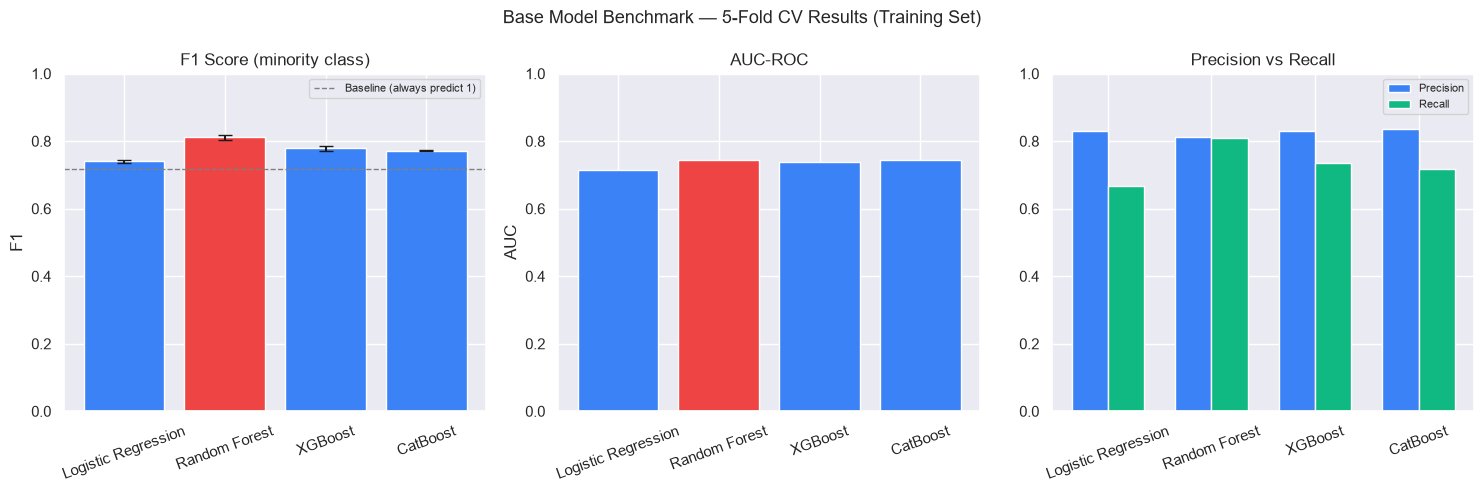

Saved: 03_benchmark_comparison.png


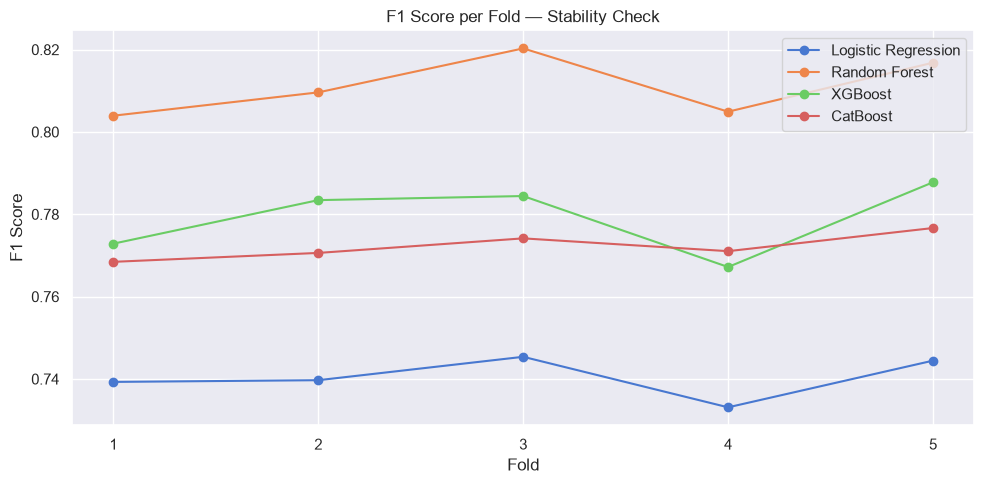

Saved: 03_fold_stability.png


In [7]:
# ── Plot 1: F1 comparison across classifiers ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Base Model Benchmark — 5-Fold CV Results (Training Set)', fontsize=13)

names  = list(cv_results.keys())
f1s    = [cv_results[n]['f1_mean']  for n in names]
f1_std = [cv_results[n]['f1_std']   for n in names]
aucs   = [cv_results[n]['auc_mean'] for n in names]
precs  = [cv_results[n]['precision_mean'] for n in names]
recs   = [cv_results[n]['recall_mean']    for n in names]

colors = ['#ef4444' if n == best_name else '#3b82f6' for n in names]

# F1 scores with error bars
axes[0].bar(names, f1s, yerr=f1_std, color=colors, capsize=5, edgecolor='white')
axes[0].set_title('F1 Score (minority class)')
axes[0].set_ylabel('F1')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(0.718, color='gray', linestyle='--', linewidth=1, label='Baseline (always predict 1)')
axes[0].legend(fontsize=8)

# AUC-ROC
axes[1].bar(names, aucs, color=colors, edgecolor='white')
axes[1].set_title('AUC-ROC')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)

# Precision vs Recall
x = np.arange(len(names))
w = 0.35
axes[2].bar(x - w/2, precs, w, label='Precision', color='#3b82f6', edgecolor='white')
axes[2].bar(x + w/2, recs,  w, label='Recall',    color='#10b981', edgecolor='white')
axes[2].set_title('Precision vs Recall')
axes[2].set_xticks(x)
axes[2].set_xticklabels(names, rotation=20)
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_benchmark_comparison.png')

# ── Plot 2: Per-fold F1 scores (stability check) ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for name, r in cv_results.items():
    folds = range(1, CV_FOLDS + 1)
    ax.plot(folds, r['fold_f1s'], marker='o', label=name, linewidth=1.5)
ax.set_xlabel('Fold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score per Fold — Stability Check')
ax.legend()
ax.set_xticks(range(1, CV_FOLDS + 1))
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_fold_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_fold_stability.png')


## 8. Winner Selection & Final Evaluation on Test Set

The best classifier is retrained on the **full training set** and evaluated
on the **held-out test set** for a final unbiased performance estimate.

This is the only time the test set is used in this notebook.


Selected classifier: Random Forest
CV F1 = 0.8111 ± 0.0065
CV AUC = 0.7444 ± 0.0054

Fitting Random Forest on full training set (16,306 games)...
Done.

=== TEST SET PERFORMANCE (Random Forest) ===
  F1 Score  : 0.8124
  AUC-ROC   : 0.7360
  Precision : 0.8169
  Recall    : 0.8079

Full classification report:
                   precision    recall  f1-score   support

Not Well Received       0.52      0.54      0.53      1151
    Well Received       0.82      0.81      0.81      2926

         accuracy                           0.73      4077
        macro avg       0.67      0.67      0.67      4077
     weighted avg       0.73      0.73      0.73      4077



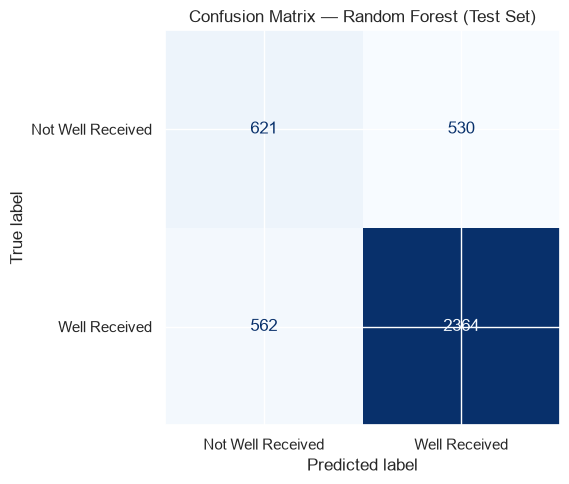

Saved: 03_confusion_matrix.png


In [8]:
# ── Select winner ─────────────────────────────────────────────────────────────
WINNER_NAME = best_name
print(f'Selected classifier: {WINNER_NAME}')
print(f'CV F1 = {cv_results[WINNER_NAME]["f1_mean"]:.4f} ± {cv_results[WINNER_NAME]["f1_std"]:.4f}')
print(f'CV AUC = {cv_results[WINNER_NAME]["auc_mean"]:.4f} ± {cv_results[WINNER_NAME]["auc_std"]:.4f}')
print()

# ── Retrain on full training set ───────────────────────────────────────────────
# CV was used for model selection — now we use all training data for final fit
winner_clf = CLASSIFIERS[WINNER_NAME]
print(f'Fitting {WINNER_NAME} on full training set ({X_train.shape[0]:,} games)...')
winner_clf.fit(X_train, y_train)
print('Done.')

# ── Evaluate on held-out test set ─────────────────────────────────────────────
y_pred      = winner_clf.predict(X_test)
y_pred_prob = winner_clf.predict_proba(X_test)[:, 1]

test_f1        = f1_score(y_test, y_pred)
test_auc       = roc_auc_score(y_test, y_pred_prob)
test_precision = precision_score(y_test, y_pred)
test_recall    = recall_score(y_test, y_pred)

print(f'\n=== TEST SET PERFORMANCE ({WINNER_NAME}) ===')
print(f'  F1 Score  : {test_f1:.4f}')
print(f'  AUC-ROC   : {test_auc:.4f}')
print(f'  Precision : {test_precision:.4f}')
print(f'  Recall    : {test_recall:.4f}')
print()
print('Full classification report:')
print(classification_report(y_test, y_pred,
                             target_names=['Not Well Received', 'Well Received']))

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Well Received', 'Well Received'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {WINNER_NAME} (Test Set)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_confusion_matrix.png')


## 9. Save Benchmark Table

In [9]:
# ── Build complete benchmark results table ─────────────────────────────────────
rows = []
for name, r in cv_results.items():
    rows.append({
        'classifier':     name,
        'cv_f1_mean':     round(r['f1_mean'], 4),
        'cv_f1_std':      round(r['f1_std'], 4),
        'cv_f1_macro':    round(r['f1_macro_mean'], 4),
        'cv_auc_mean':    round(r['auc_mean'], 4),
        'cv_auc_std':     round(r['auc_std'], 4),
        'cv_precision':   round(r['precision_mean'], 4),
        'cv_recall':      round(r['recall_mean'], 4),
        'train_time_sec': round(r['time_sec'], 1),
        'is_winner':      name == WINNER_NAME,
        # Test set metrics (only for winner)
        'test_f1':        round(test_f1, 4)        if name == WINNER_NAME else None,
        'test_auc':       round(test_auc, 4)        if name == WINNER_NAME else None,
        'test_precision': round(test_precision, 4)  if name == WINNER_NAME else None,
        'test_recall':    round(test_recall, 4)     if name == WINNER_NAME else None,
    })

benchmark_df = pd.DataFrame(rows)
benchmark_df.to_csv(RESULTS_DIR / 'benchmark_table.csv', index=False)
print(f'Saved: {RESULTS_DIR / "benchmark_table.csv"}')
print()
print('=== BENCHMARK TABLE ===')
print(benchmark_df.to_string(index=False))


Saved: C:\Users\3214h\Documents\fyp-steam-reception\outputs\results\benchmark_table.csv

=== BENCHMARK TABLE ===
         classifier  cv_f1_mean  cv_f1_std  cv_f1_macro  cv_auc_mean  cv_auc_std  cv_precision  cv_recall  train_time_sec  is_winner  test_f1  test_auc  test_precision  test_recall
Logistic Regression      0.7404     0.0044       0.6311       0.7158      0.0079        0.8297     0.6685          0.4000      False      NaN       NaN             NaN          NaN
      Random Forest      0.8111     0.0065       0.6677       0.7444      0.0054        0.8134     0.8089          8.1000       True   0.8124    0.7360          0.8169       0.8079
            XGBoost      0.7791     0.0078       0.6591       0.7379      0.0069        0.8304     0.7340          2.7000      False      NaN       NaN             NaN          NaN
           CatBoost      0.7722     0.0029       0.6580       0.7443      0.0058        0.8360     0.7175         11.9000      False      NaN       NaN            

## 10. Summary

In [10]:
print('=' * 65)
print('NOTEBOOK 03 — BASE MODEL BENCHMARK SUMMARY')
print('=' * 65)

print(f'\nDATASET')
print(f'  Total games    : {len(df):,}')
print(f'  Features (T4)  : {len(T4_FEATURES)}')
print(f'  Train set      : {X_train.shape[0]:,} games')
print(f'  Test set       : {X_test.shape[0]:,} games')
print(f'  CV strategy    : {CV_FOLDS}-fold stratified')

print(f'\nCLASSIFIER RANKING (by CV F1):')
ranked = sorted(cv_results.items(), key=lambda x: x[1]['f1_mean'], reverse=True)
for rank, (name, r) in enumerate(ranked, 1):
    winner_marker = ' ← WINNER' if name == WINNER_NAME else ''
    print(f'  {rank}. {name:<25} F1={r["f1_mean"]:.4f} ± {r["f1_std"]:.4f}  '
          f'AUC={r["auc_mean"]:.4f}{winner_marker}')

print(f'\nWINNER: {WINNER_NAME}')
print(f'  CV  F1  : {cv_results[WINNER_NAME]["f1_mean"]:.4f} ± {cv_results[WINNER_NAME]["f1_std"]:.4f}')
print(f'  CV  AUC : {cv_results[WINNER_NAME]["auc_mean"]:.4f}')
print(f'  Test F1 : {test_f1:.4f}')
print(f'  Test AUC: {test_auc:.4f}')

print(f'\nIMBALANCE STRATEGY: {best_strategy}')

print(f'\nNEXT STEP: Notebook 04 — Specialist Models + Router')
print(f'  Train Models A (T1), B (T2), C (T3), D (T4) using {WINNER_NAME}')
print(f'  Implement confidence-based router')
print(f'  Run tier degradation ablation T1 → T2 → T3 → T4')
print('=' * 65)


NOTEBOOK 03 — BASE MODEL BENCHMARK SUMMARY

DATASET
  Total games    : 20,383
  Features (T4)  : 53
  Train set      : 16,306 games
  Test set       : 4,077 games
  CV strategy    : 5-fold stratified

CLASSIFIER RANKING (by CV F1):
  1. Random Forest             F1=0.8111 ± 0.0065  AUC=0.7444 ← WINNER
  2. XGBoost                   F1=0.7791 ± 0.0078  AUC=0.7379
  3. CatBoost                  F1=0.7722 ± 0.0029  AUC=0.7443
  4. Logistic Regression       F1=0.7404 ± 0.0044  AUC=0.7158

WINNER: Random Forest
  CV  F1  : 0.8111 ± 0.0065
  CV  AUC : 0.7444
  Test F1 : 0.8124
  Test AUC: 0.7360

IMBALANCE STRATEGY: no_weighting

NEXT STEP: Notebook 04 — Specialist Models + Router
  Train Models A (T1), B (T2), C (T3), D (T4) using Random Forest
  Implement confidence-based router
  Run tier degradation ablation T1 → T2 → T3 → T4
